In [101]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
cleaned_customer_transaction_data = pd.read_csv(r"C:/Users/user/Downloads/Fraudulent_Transaction_Detection_for_Finlora_Company/Finlora_dataset/artifacts/cleaned_Data.csv")

In [103]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.1,
    palette='Spectral'
)

### Distribution of Fraud and Transaction Channels


In [104]:
cleaned_customer_transaction_data.head()

,Unnamed: 0,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.19,278.19,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [105]:
cleaned_customer_transaction_data.columns

Index(['Unnamed: 0', 'transaction_id', 'customer_id', 'timestamp',
       'home_country', 'source_currency', 'dest_currency', 'channel',
       'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'device_id', 'new_device', 'ip_address', 'ip_country',
       'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days',
       'device_trust_score', 'chargeback_history_count', 'risk_score_internal',
       'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='object')

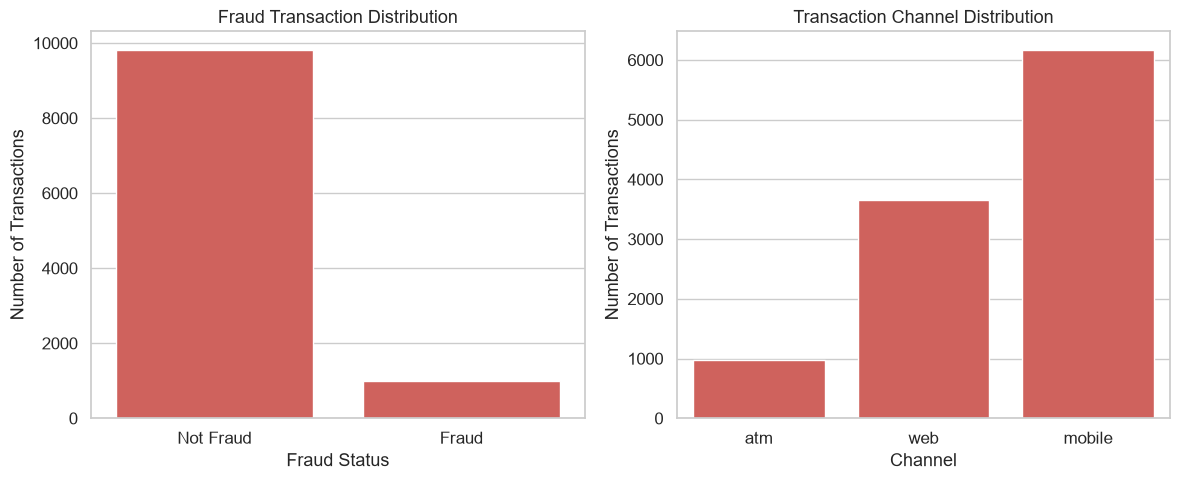

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Fraud distribution
sns.countplot(cleaned_customer_transaction_data, x='is_fraud' , ax=axes[0])
axes[0].set_title('Fraud Transaction Distribution')
axes[0].set_xlabel('Fraud Status')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Not Fraud','Fraud'])

# Channel distribution
sns.countplot(cleaned_customer_transaction_data, x='channel',ax=axes[1])
axes[1].set_title('Transaction Channel Distribution')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.show()


### Distribution of Fraud and Transaction Channels

To get have an initial understanding of the dataset so as to carry out a proper exploratory data analysis(EDA) stage. A fraud distribution chart is plotted to determine the balance/distribution of fraudulent and legitimate transactions.
This step is very important for fraud detection because a target variable that is imbalanced can cause a machine learning model to favour the majority class and perform poorly when identifying fraudulent transactions.Understanding the level of class imbalance will help us determine whether techniques such as class weighting, resampling, or appropriate evaluation matrics may be required.
The transaction channel distribution chart shows how thw transactions are distributed across different channels, such as mobile, online, ATM, and other available channels. Eaxmining this distribution helps us identify dormant or less represented transaction channels and provides an initial indication of wether the channel may be relevant to fraudulent behaviour. These observations will guide subsequent feature analysis and the development of a model.

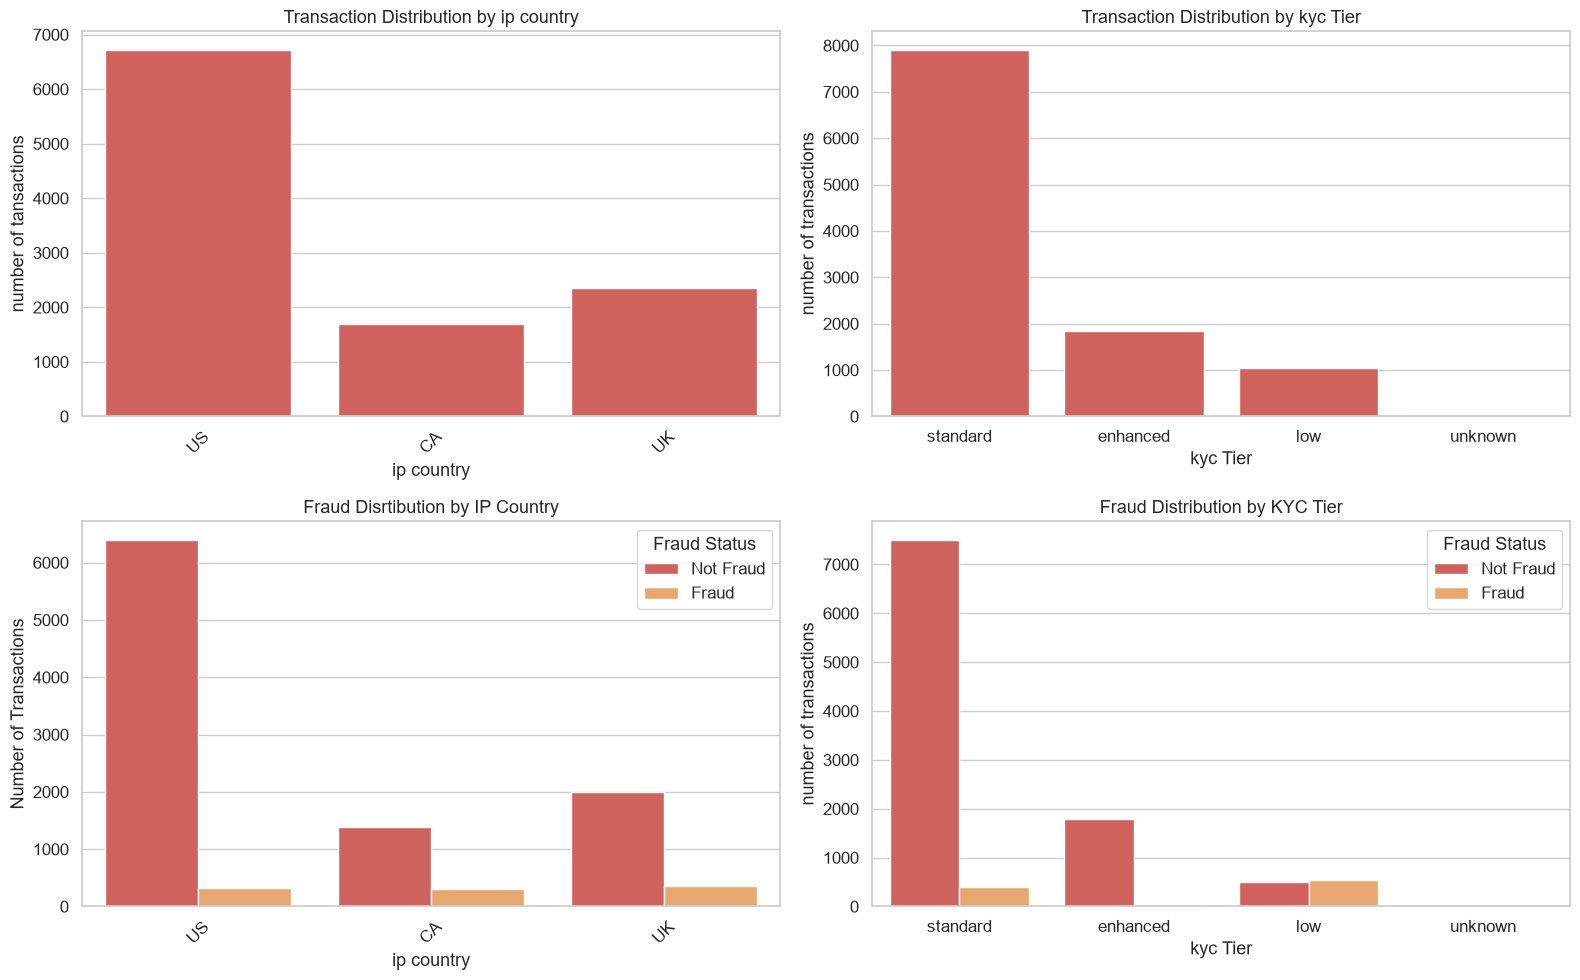

In [107]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. IP Country distribution
sns.countplot(
    data=cleaned_customer_transaction_data,
    x='ip_country',ax=axes[0, 0]
)
axes[0, 0].set_title('Transaction Distribution by ip country')
axes[0, 0].set_xlabel('ip country')
axes[0, 0].set_ylabel('number of tansactions')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. KYC Tier distribution
sns.countplot(
    data=cleaned_customer_transaction_data,
    x='kyc_tier',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Transaction Distribution by kyc Tier')
axes[0, 1].set_xlabel('kyc Tier')
axes[0, 1].set_ylabel('number of transactions')

# 3.IP Country VS Fraud
sns.countplot(
    data=cleaned_customer_transaction_data,
    x='ip_country',
    hue='is_fraud',
    ax=axes[1, 0]         
)
axes[1, 0].set_title('Fraud Disrtibution by IP Country')
axes[1, 0].set_xlabel('ip country')
axes[1, 0].set_ylabel('Number of Transactions')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0]. legend(title='Fraud Status',labels=['Not Fraud', 'Fraud'])

# 4. KYC Tier vs Fraud
sns.countplot(
    cleaned_customer_transaction_data,
    x='kyc_tier',
    hue='is_fraud',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Fraud Distribution by KYC Tier')
axes[1, 1].set_xlabel('kyc Tier')
axes[1, 1].set_ylabel('number of transactions')
axes[1, 1].legend(title='Fraud Status',labels=['Not Fraud','Fraud'])

plt.tight_layout()
plt.show()

### IP Country and KYC Tier Analysis

These charts shows an overview of the distribution of transactions across IP conrties and KYC tiers, while also examining their relationship with relationship and transactions. The IP country distribution helps identify the countries from which transactions are predominantly initiated and highlights countries that may be underrepresented in the dataset. Similarly the kyc tier distribution shows how transactions are distributed across different levels of customer verification, providing an understanding of the compostion of the customer base. 

Then IP country versus fraud chart compares fraudulent and legitimate transactions across countries. This is useful for identifying if fraudulent transactions are concentrated within a particular geographic location, which may indicate potential geographic patterns that may be relevant to fraud detection. We will also need to consider differences in the total number of transactions across countries should be considered when interpreating the results.

The KYC tier versus fraud chart eaxmines the distribution of fraudulent and legitimate transactions across different KYC verifrication levels. This analysis can help determine if fraud occurences varied across customer verification tiers and whether KYC status may provide useful predictive information for the fraud detection model. 

In summarry, these visualisations help identify potential patterns and relationships between customer verifrication, transaction origin, and fraudulent behaviour, which can inform susequent feature engineering and machine model develpoment.

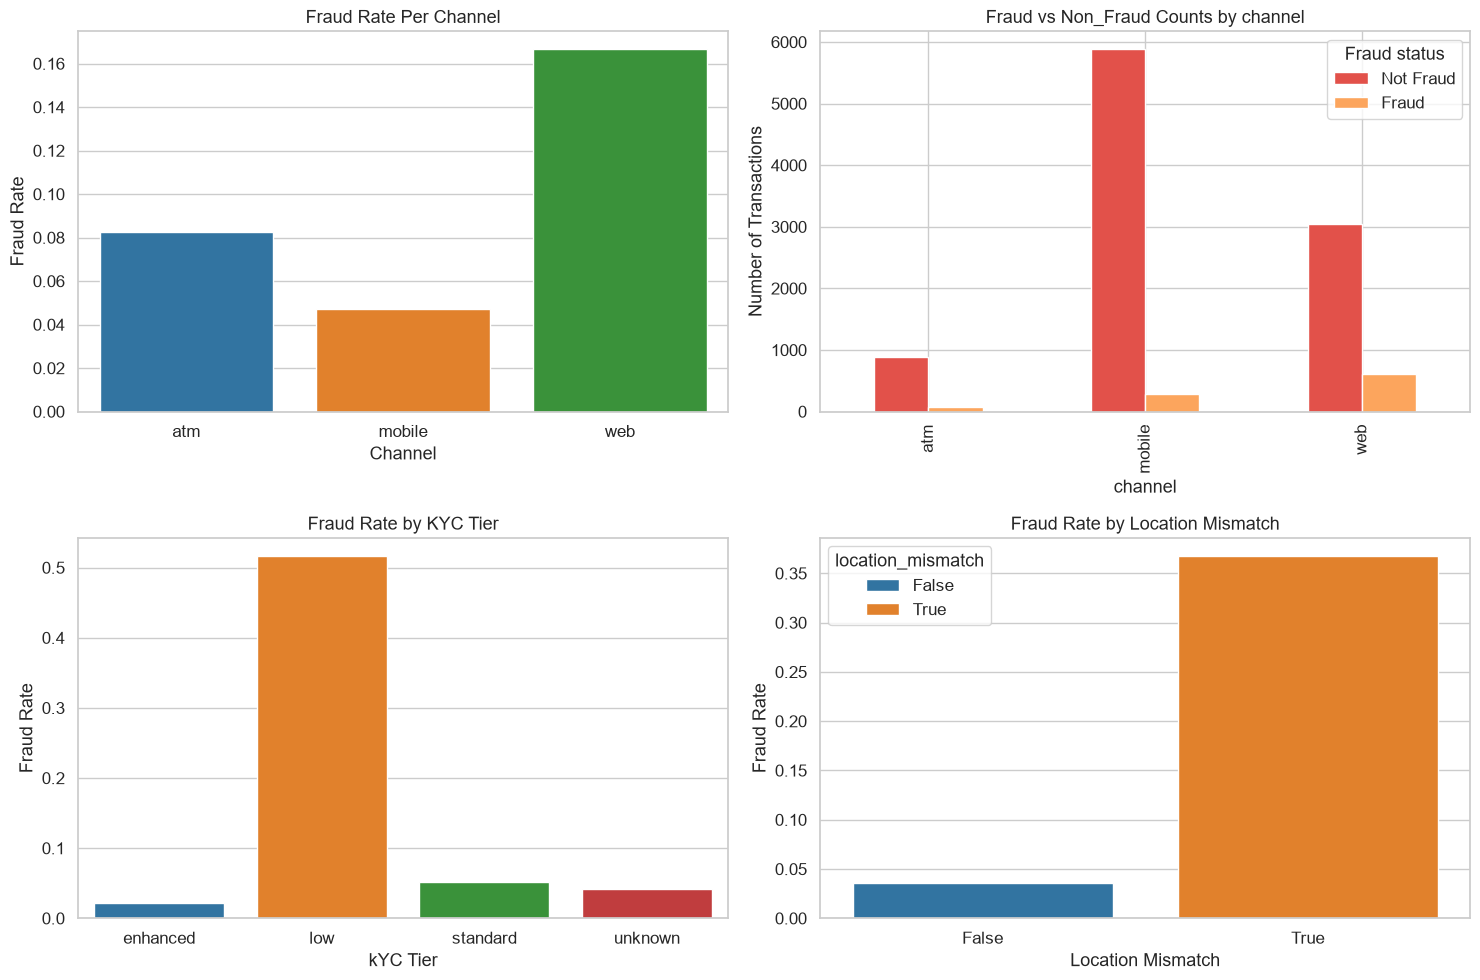

In [108]:
# 1. Fraud rate per channel

channel_fraud_rate = cleaned_customer_transaction_data.groupby('channel')['is_fraud'].mean().reset_index()
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.barplot(
    data=channel_fraud_rate,
    x='channel',
    y='is_fraud',
    ax=axes[0, 0],
    hue='channel',
    palette='tab10',
    legend=False
)

axes[0, 0].set_title('Fraud Rate Per Channel')
axes[0, 0].set_xlabel('Channel')
axes[0, 0].set_ylabel('Fraud Rate')

# 2. Fraud vs Non-Fraud counts per channel

Channel_counts = (
    cleaned_customer_transaction_data.groupby('channel')['is_fraud']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

Channel_counts = Channel_counts.rename(
    columns={0: 'Not Fraud', 1: 'Fraud'}
)

Channel_counts.plot(
    x='channel',
    y=['Not Fraud', 'Fraud'],
    kind='bar',
    ax=axes[0, 1]
)

axes[0, 1].set_title('Fraud vs Non_Fraud Counts by channel')
axes[0, 1].set_xlabel('channel')
axes[0, 1].set_ylabel('Number of Transactions')
axes[0, 1].legend(title= 'Fraud status')

# 3. Fraud rate per kyc tier

kyc_fraud_rate = cleaned_customer_transaction_data.groupby('kyc_tier')['is_fraud'].mean().reset_index()

sns.barplot(
    data=kyc_fraud_rate,
    x='kyc_tier',
    y='is_fraud',
    ax=axes[1, 0],
    hue='kyc_tier',
    palette='tab10'
)

axes[1, 0].set_title('Fraud Rate by KYC Tier')
axes[1, 0].set_xlabel('kYC Tier')
axes[1, 0].set_ylabel('Fraud Rate')


# 4. Fraud rate per location mismatch

location_fraud_rate=(
    cleaned_customer_transaction_data.groupby('location_mismatch')['is_fraud']
    .mean()
    .reset_index()
                      
    
)
sns.barplot(
    data=location_fraud_rate,
    x='location_mismatch',
    y='is_fraud',ax=axes[1, 1],
    hue='location_mismatch',
    palette='tab10'
)

axes[1, 1].set_title('Fraud Rate by Location Mismatch')
axes[1, 1].set_xlabel('Location Mismatch')
axes[1, 1].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.show()



### Fraud Rate Analysis by Location Mismatch, KYC Tier, and Transaction Channel

These graphs show how fraudulent transaction behaviour varies across location mismatch, KYC verification level and transaaction channel. The location mismatch analysis indicates a tangible difference in fraud risk depending on wether transaction occures in an expected location, Transactions where location_mismatch= false, meaning the transaction location is consistent with the user's expected or previously observed location, have a relatively low fraud rate of approximately 3-5%. In contrast, transactions where location_mismatch = true, indicating an unexpected or ususual transaction location, these have a considerably higher fraud rate of over 35%. Considering the rates observed, transactions with a location mismatch are approximately 7-9 times more likely to be fraudulent than transactions without a location mismatch. This suggests that location mismatch may be an important predictive feature for identifying potentially fraudulent transactions. 

KYC tier analysis also shows differences in fraud risk across customer verification levels. This results shoow that customers with lower levels of KYC verification have hgher fraud rates, while those with enhanced verification havt the lowest observed fraud risk.
This suggests that the level of customer verification may provide useful information for distinguishing between legitimate and potentially fraudulent transactions.
Transaction channel analysis provides two perspectives that are complementary. The fraud-rate chart measures the proportion of transactions that are fraudulent within each channel, while the fraud-count chart measures the actual number of fraudulent and non-fraudulent transactions. The results indicate that web transactions have a higher fraud rate than mobile transactions, suggesting that the web channel may present a relatively higher fraud risk. However, fraud count should be interpreted alongside fraud rates because differences in the total number of transactions across channels can influence the absolute number of fraudulent transactions.

### Fraud Rate by Transaction Velocity

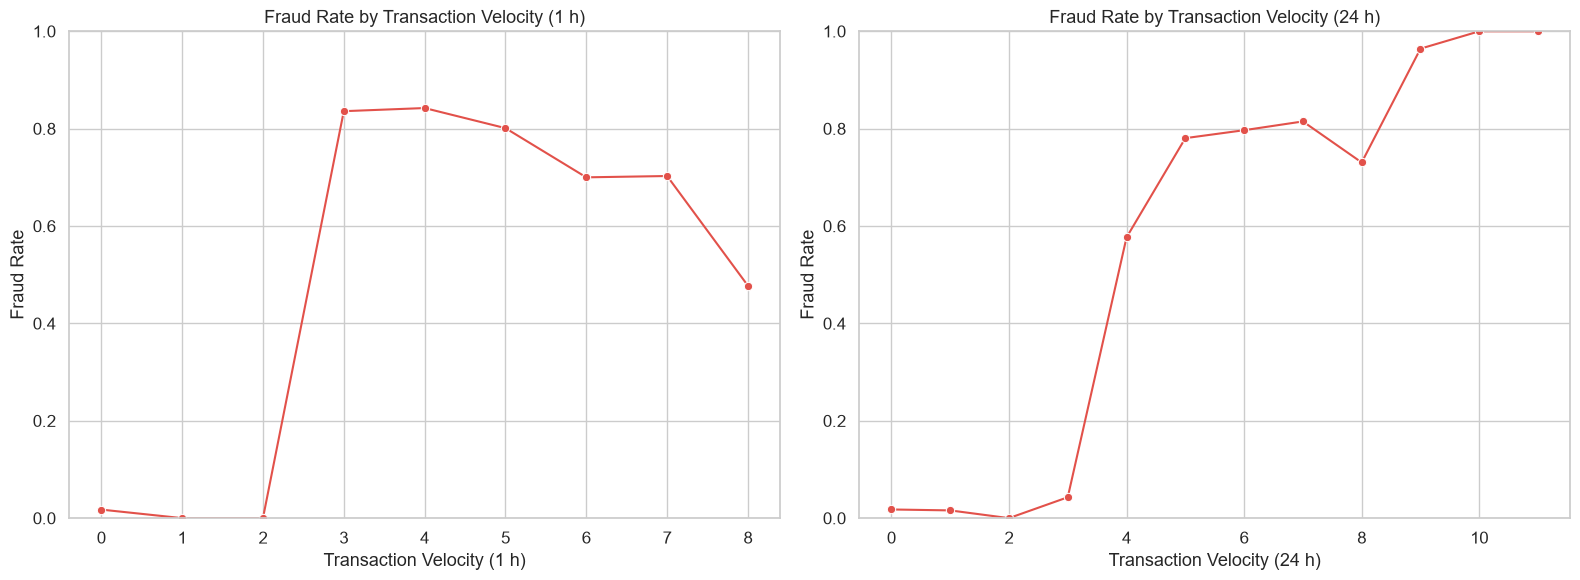

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fraud rate by transaction velocity (1 hour)
txn_velocity_1hour =( 
    cleaned_customer_transaction_data.groupby('txn_velocity_1h')['is_fraud']
    .mean()
    .reset_index()
)

sns.lineplot(
    data=txn_velocity_1hour,
    x='txn_velocity_1h',
    y='is_fraud',
    marker='o',
    ax=axes[0]
)

axes[0].set_title('Fraud Rate by Transaction Velocity (1 h)')
axes[0].set_xlabel('Transaction Velocity (1 h)')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_ylim(0, 1)

# 2. Fraud rate by transaction velocity (24 hours)
txn_velocity_24h = (
    cleaned_customer_transaction_data.groupby('txn_velocity_24h')['is_fraud']
    .mean()
    .reset_index()
)

sns.lineplot(
    data=txn_velocity_24h,
    x='txn_velocity_24h',
    y='is_fraud',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Fraud Rate by Transaction Velocity (24 h)')
axes[1].set_xlabel('Transaction Velocity (24 h)')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### Fraud Rate by Hour

In [110]:
cleaned_customer_transaction_data['timestamp'] = pd.to_datetime(
    cleaned_customer_transaction_data['timestamp'],
    format='mixed',
    errors='coerce',
    utc=True
)

C:\Users\user\AppData\Local\Temp\ipykernel_43280\1783915119.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


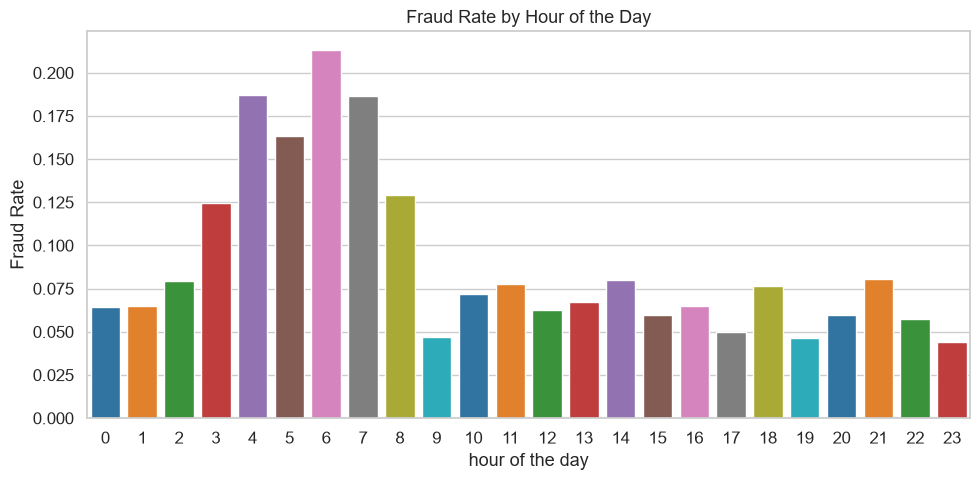

In [111]:
cleaned_customer_transaction_data['timestamp'] = pd.to_datetime(cleaned_customer_transaction_data['timestamp'])
# Extract time-based features
cleaned_customer_transaction_data['hour'] = cleaned_customer_transaction_data['timestamp'].dt.hour
cleaned_customer_transaction_data['day_of_week'] = cleaned_customer_transaction_data['timestamp'].dt.dayofweek
cleaned_customer_transaction_data['is weekend']=(cleaned_customer_transaction_data['day_of_week'] >= 5).astype(int)
cleaned_customer_transaction_data['month'] = cleaned_customer_transaction_data['timestamp'].dt.month

#Fraud by hour
fraud_by_hour =( 
    cleaned_customer_transaction_data.groupby('hour')['is_fraud']
    .mean()
    .reset_index()
)

# plot
plt.figure(figsize=(10, 5))

sns.barplot(
    data=fraud_by_hour,
    x='hour',
    y='is_fraud',
    palette='tab10'
)

plt.xlabel('hour of the day')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour of the Day')

plt.tight_layout()
plt.show()




C:\Users\user\AppData\Local\Temp\ipykernel_43280\3647442083.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


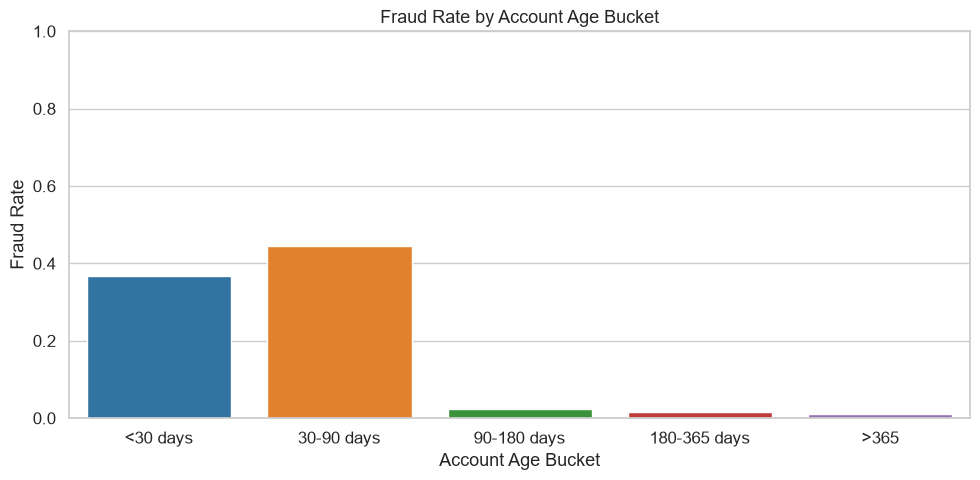

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

# create account age buckets
cleaned_customer_transaction_data['account_age_bucket'] = pd.cut(
    cleaned_customer_transaction_data['account_age_days'],
    bins=[0, 30, 90, 180, 365, 2000],
    labels=['<30 days', '30-90 days', '90-180 days', '180-365 days', '>365']
)

#Calculate fraud rate by account age buckets
fraud_rate_by_account_age = (
    cleaned_customer_transaction_data.groupby('account_age_bucket',observed=True)['is_fraud']
    .mean()
    .reset_index()
)

# plot
plt.figure(figsize=(10, 5))
sns.barplot(
    data=fraud_rate_by_account_age,
    x='account_age_bucket',
    y='is_fraud',
    palette='tab10'
)


plt.xlabel('Account Age Bucket')
plt.ylabel('Fraud Rate')
plt.ylim(0, 1)
plt.title('Fraud Rate by Account Age Bucket')

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_43280\3612586391.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\user\AppData\Local\Temp\ipykernel_43280\3612586391.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\user\AppData\Local\Temp\ipykernel_43280\3612586391.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


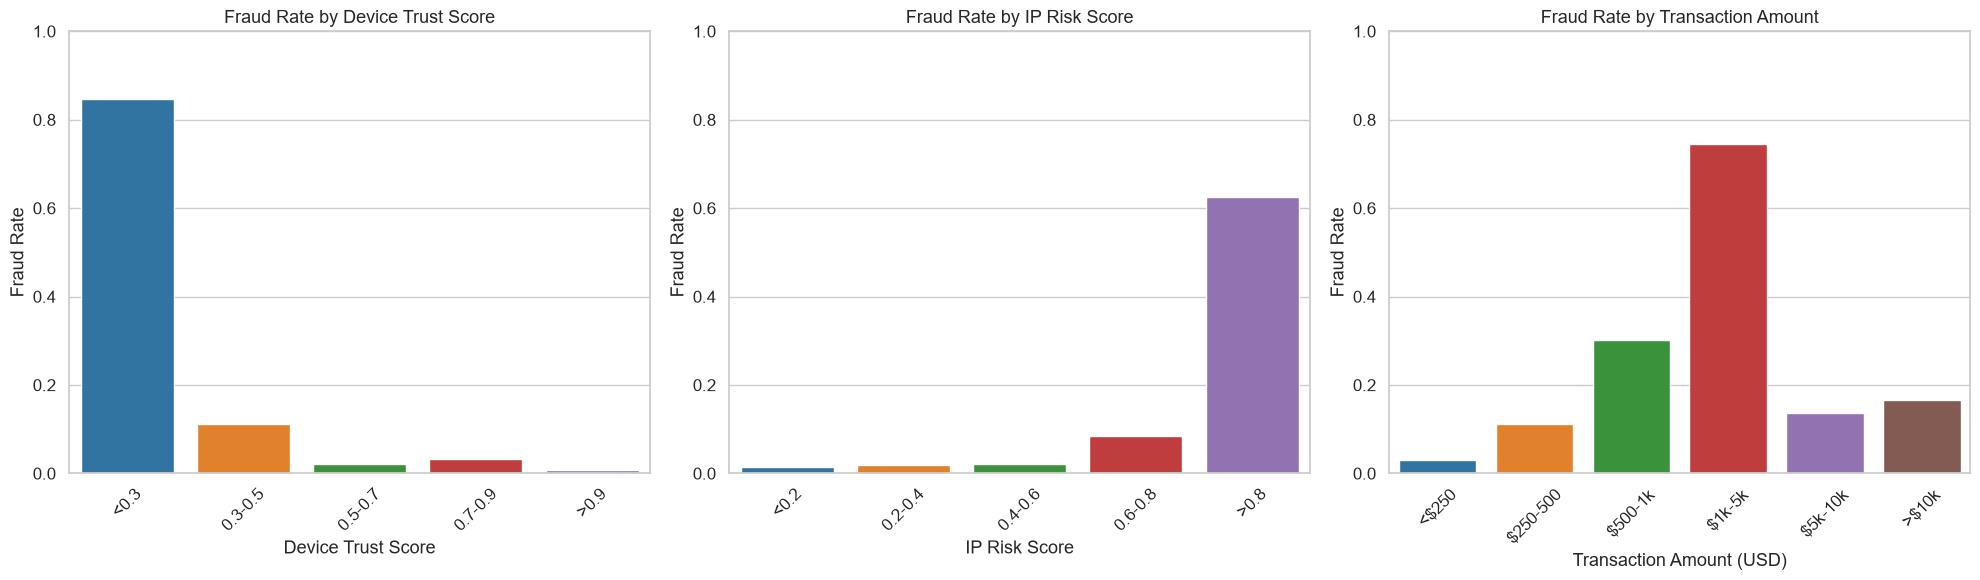

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns


# create 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Fraud Rate by Device Trust Score

cleaned_customer_transaction_data['device_trust_score_bucket']= pd.cut(
    cleaned_customer_transaction_data['device_trust_score'],
    bins=[0, 0.3, 0.5, 0.7, 0.9, 1.0],
    labels=['<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9', '>0.9'],
    include_lowest=True
)
fraud_rate_by_device_trust_score = (
    cleaned_customer_transaction_data.groupby(
        'device_trust_score_bucket',
        observed=True
    )['is_fraud']
    .mean()
    .reset_index()
)    

sns.barplot(
    data = fraud_rate_by_device_trust_score,
    x='device_trust_score_bucket',
    y='is_fraud',
    ax=axes[0],
    palette='tab10'
)

axes[0].set_xlabel('Device Trust Score')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_ylim(0, 1)
axes[0].set_title('Fraud Rate by Device Trust Score')
axes[0].tick_params(axis='x', rotation=45)


# 2. Fraud Rate by IP Risk Score

cleaned_customer_transaction_data['ip_risk_score_bucket'] = pd.cut(
    cleaned_customer_transaction_data['ip_risk_score'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.8],
    labels=['<0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '>0.8'],
    include_lowest=True
)

# Fraud rate by ip risk score
fraud_by_ip_risk_score = (
    cleaned_customer_transaction_data.groupby(
        'ip_risk_score_bucket',
        observed=True
    )['is_fraud']
    .mean()
    .reset_index()
)

sns.barplot(
    data=fraud_by_ip_risk_score,
    x='ip_risk_score_bucket',
    y='is_fraud',
    ax=axes[1],
    palette = 'tab10'
)

axes[1].set_xlabel('IP Risk Score')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_ylim(0, 1)
axes[1].set_title('Fraud Rate by IP Risk Score')
axes[1].tick_params(axis='x', rotation=45)


# 3. Fraud Rate by Transaction Amount
cleaned_customer_transaction_data['amount_usd_bucket'] = pd.cut(
    cleaned_customer_transaction_data['amount_usd'],
    bins=[0, 250, 500, 1000, 5000, 10000, 20000],
    labels=[
        '<$250', 
        '$250-500', 
        '$500-1k',
        '$1k-5k', 
        '$5k-10k',
        '>$10k'
    ],
    include_lowest=True
)

 # Fraud Rate by amout USD
fraud_rate_by_amount_usd = (
    cleaned_customer_transaction_data.groupby(
        'amount_usd_bucket', 
        observed=True
    )['is_fraud']
    .mean()
    .reset_index()
)
sns.barplot(
    data=fraud_rate_by_amount_usd,
    x='amount_usd_bucket',
    y='is_fraud',
    ax=axes[2],
    palette= 'tab10'
)

axes[2].set_xlabel('Transaction Amount (USD)')
axes[2].set_ylabel('Fraud Rate')
axes[2].set_ylim(0, 1)
axes[2].set_title('Fraud Rate by Transaction Amount')
axes[2].tick_params(axis='x', rotation=45)


#Final Layout

plt.tight_layout()
plt.show()

In [114]:
cleaned_customer_transaction_data.shape

(10804, 35)

In [115]:
cleaned_customer_transaction_data.columns

Index(['Unnamed: 0', 'transaction_id', 'customer_id', 'timestamp',
       'home_country', 'source_currency', 'dest_currency', 'channel',
       'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'device_id', 'new_device', 'ip_address', 'ip_country',
       'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days',
       'device_trust_score', 'chargeback_history_count', 'risk_score_internal',
       'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud',
       'hour', 'day_of_week', 'is weekend', 'month', 'account_age_bucket',
       'device_trust_score_bucket', 'ip_risk_score_bucket',
       'amount_usd_bucket'],
      dtype='object')

In [116]:
from pathlib import Path

artifacts_dir = Path("../Finlora_dataset/artifacts")

artifacts_dir.mkdir(parents=True, exist_ok=True)

print("Artifacts directory:", artifacts_dir.resolve())

Artifacts directory: C:\Users\user\Downloads\Fraudulent_Transaction_Detection_for_Finlora_Company\Finlora_dataset\artifacts


In [117]:
cleaned_customer_transaction_data.to_csv('../Finlora_Dataset/artifacts/EDA_Data.csv', index=False)

In [118]:
cleaned_customer_transaction_data=pd.read_csv(r"C:\Users\user\Downloads\Fraudulent_Transaction_Detection_for_Finlora_Company\Finlora_dataset\artifacts\EDA_Data.csv")

In [119]:
cleaned_customer_transaction_data.shape

(10804, 35)